In [50]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

In [51]:
dados = pd.read_csv(r'C:\Users\ashto\OneDrive\Documents\Python_\Cálculo_Numérico\Grupo02 (1).csv', sep =';')
dados['Precipitação'] = dados['Precipitação'].str.replace(',','.').astype(float)
dados

,Mês,Precipitação
0,1,144.4
1,2,150.0
2,3,125.8
3,4,94.0
4,5,111.0
5,6,262.2
6,7,149.8
7,8,186.0
8,9,188.4
9,10,231.3


In [52]:
x_dados = dados['Mês']
y_dados = dados['Precipitação']

In [53]:
# x => mês
# A0, A1, B1 coeficientes

def modelo_trigonometrico(x, A0, A1, B1):
    """
    período fixo em 12 meses
    """
    
    return A0 + A1*np.cos(2*np.pi * x /12) + B1 *np.sin(2*np.pi *x /12)


# curve_fit usa o metodo dos minimos quadrados para encontrar os melhores coeficientes A0, A1, B1
# `popt` conterá os coeficientes ótimos [A0, A1, B1]
# `pcov` é a matriz de covariância, que pode ser usada para calcular a incerteza dos parâmetros.
params_otimos, pcov = curve_fit(modelo_trigonometrico, x_dados, y_dados)

A0_fit, A1_fit, B1_fit = params_otimos
print("--- Coeficientes Encontrados ---")
print(f"A0 (Média de precipitação ajustada): {A0_fit:.2f}")
print(f"A1 (Coeficiente do cosseno): {A1_fit:.2f}")
print(f"B1 (Coeficiente do seno): {B1_fit:.2f}")
print("\nFunção final F(x) = {:.2f} + {:.2f}*cos(2*pi*x/12) + {:.2f}*sin(2*pi*x/12)".format(A0_fit, A1_fit, B1_fit))

--- Coeficientes Encontrados ---
A0 (Média de precipitação ajustada): 133.36
A1 (Coeficiente do cosseno): 28.24
B1 (Coeficiente do seno): -60.72

Função final F(x) = 133.36 + 28.24*cos(2*pi*x/12) + -60.72*sin(2*pi*x/12)



--- Previsão ---
A precipitação estimada para o mês 72 é: 161.60 mm


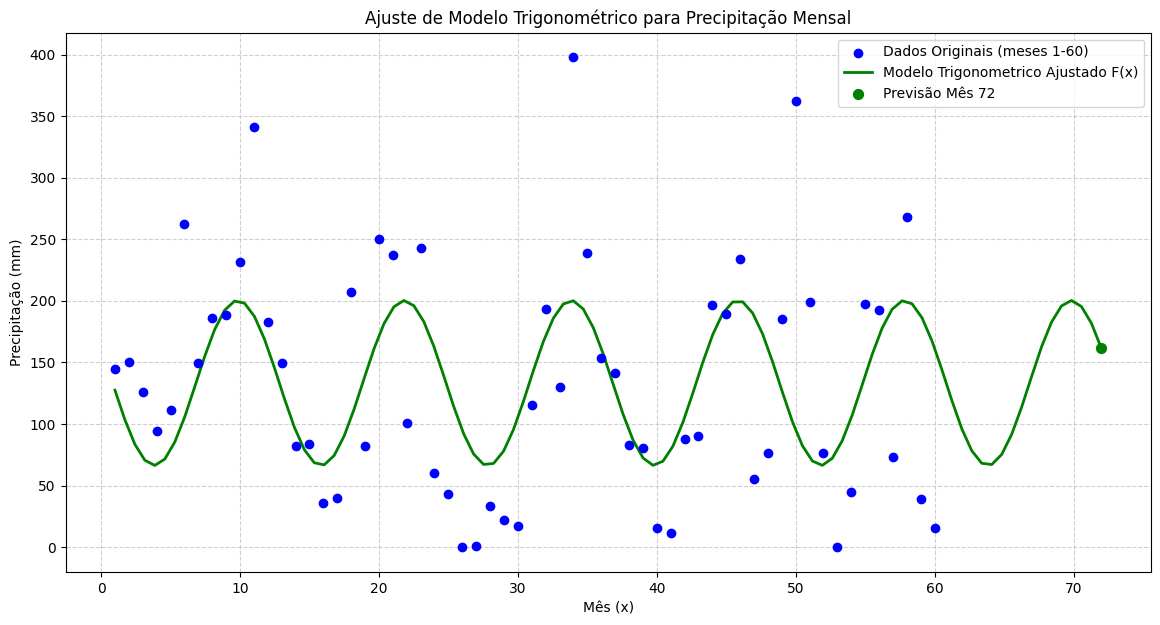

In [ ]:
#visualizar

x_curva = np.linspace(1,72,300)
y_curva = modelo_trigonometrico(x_curva, *params_otimos) # * para desempacotar

plt.figure(figsize=(14,7))
plt.scatter(x_dados,y_dados,label='Dados Originais (meses 1-60)', color = 'blue', zorder=5)
plt.plot(x_curva,y_curva, label='Modelo Trigonometrico Ajustado F(x)', color ='green', linewidth = 2)

plt.title('Ajuste de Modelo Trigonométrico para Precipitação Mensal')
plt.xlabel('Mês (x)')
plt.ylabel('Precipitação (mm)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

mes_futuro = 72
precipitacao_prevista = modelo_trigonometrico(mes_futuro,*params_otimos)
print(f"\n--- Previsão ---")
print(f"A precipitação estimada para o mês {mes_futuro} é: {precipitacao_prevista:.2f} mm")

plt.scatter(mes_futuro, precipitacao_prevista, color='green', marker='.', s=200, label=f'Previsão Mês {mes_futuro}', zorder=10)
plt.legend()
plt.show()

--- Previsão para o Mês 72 (para cada ordem) ---
Ordem 1: 161.60 mm
Ordem 2: 141.88 mm
Ordem 3: 116.34 mm
Ordem 4: 103.82 mm


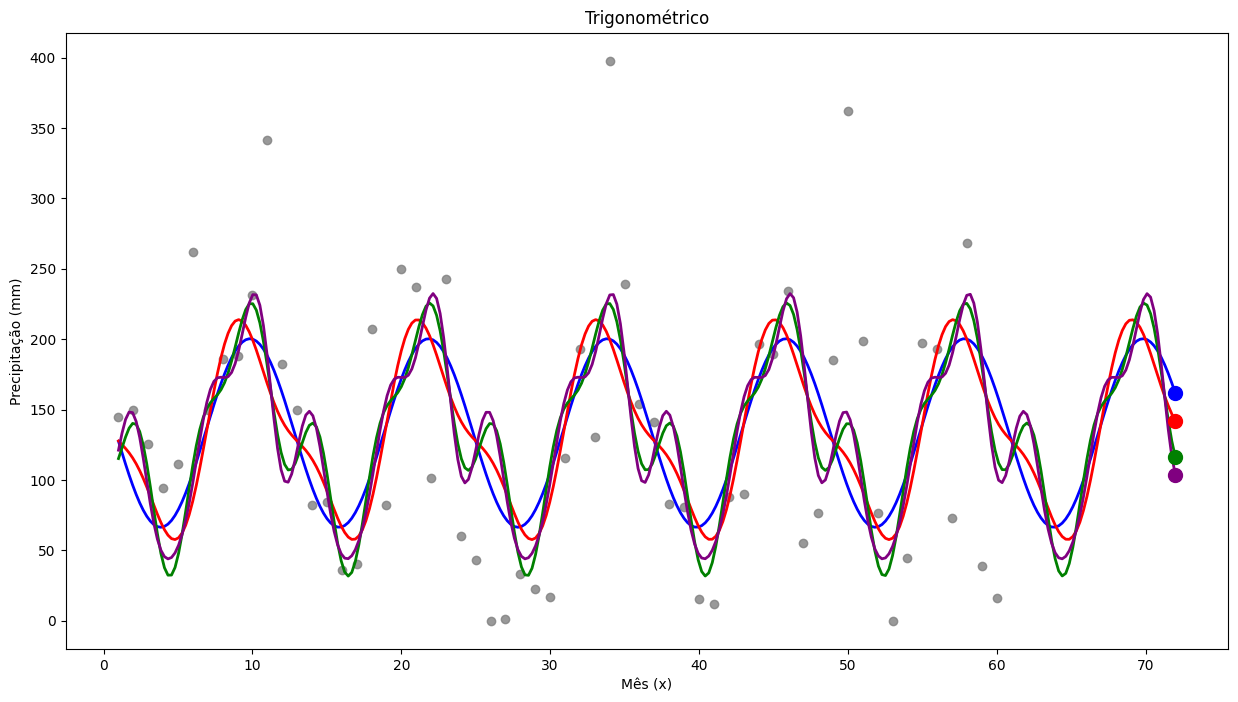

In [69]:
m = len(x_dados)

# --- A Função de Modelo Geral ---
def modelo_trigonometrico_geral(x, *params):
    y = params[0]
    for k in range(1, len(params), 2):
        ordem_k = (k + 1) // 2
        Ak = params[k]
        Bk = params[k+1]
        termo_cos = Ak * np.cos(2 * np.pi * ordem_k * x / 12)
        termo_sin = Bk * np.sin(2 * np.pi * ordem_k * x / 12)
        y = y + termo_cos + termo_sin
    return y

# --- Loop para Testar Ordens e Mostrar Previsões ---
plt.figure(figsize=(15, 8))
plt.scatter(x_dados, y_dados, label='Dados Originais', color='gray', alpha=0.8)

print("--- Previsão para o Mês 72 (para cada ordem) ---")

# Lista de cores para as curvas e pontos
cores = ['blue', 'red', 'green', 'purple']

for i, ordem_n in enumerate(range(1, 5)):
    num_params = 1 + 2 * ordem_n
    chute_inicial = [np.mean(y_dados)] + [0.0] * (2 * ordem_n)
    
    try:
        params_otimos, _ = curve_fit(modelo_trigonometrico_geral, x_dados, y_dados, p0=chute_inicial, maxfev=10000)
        
        # Plotar a curva do modelo
        x_curva = np.linspace(1, 72, 300)
        y_curva = modelo_trigonometrico_geral(x_curva, *params_otimos)
        cor_atual = cores[i % len(cores)] # Seleciona a cor
        plt.plot(x_curva, y_curva, label=f'Ordem {ordem_n}', color=cor_atual, linewidth=2)
        
        # Calcular e mostrar a previsão para esta ordem
        mes_futuro = 72
        precipitacao_prevista = modelo_trigonometrico_geral(mes_futuro, *params_otimos)
        print(f"Ordem {ordem_n}: {precipitacao_prevista:.2f} mm")
        
        # Destacar o ponto da previsão no gráfico
        plt.scatter(mes_futuro, precipitacao_prevista, color=cor_atual, marker='o', s=100, zorder=10)

    except RuntimeError:
        print(f"Ordem {ordem_n}: Não foi possível ajustar o modelo.")

# --- Finalizar o gráfico ---
plt.title('Trigonométrico')
plt.xlabel('Mês (x)')
plt.ylabel('Precipitação (mm)')
# plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Interpolação polinomial

Ajustando um polinômio de grau 59...

--- Previsão com Interpolação Polinomial ---
A precipitação estimada para o mês 72 é: 1.085978e+15


C:\Users\ashto\AppData\Local\Temp\ipykernel_18492\1048595633.py:12: RankWarning: Polyfit may be poorly conditioned
  coeficientes = np.polyfit(x_dados, y_dados, grau_polinomio)


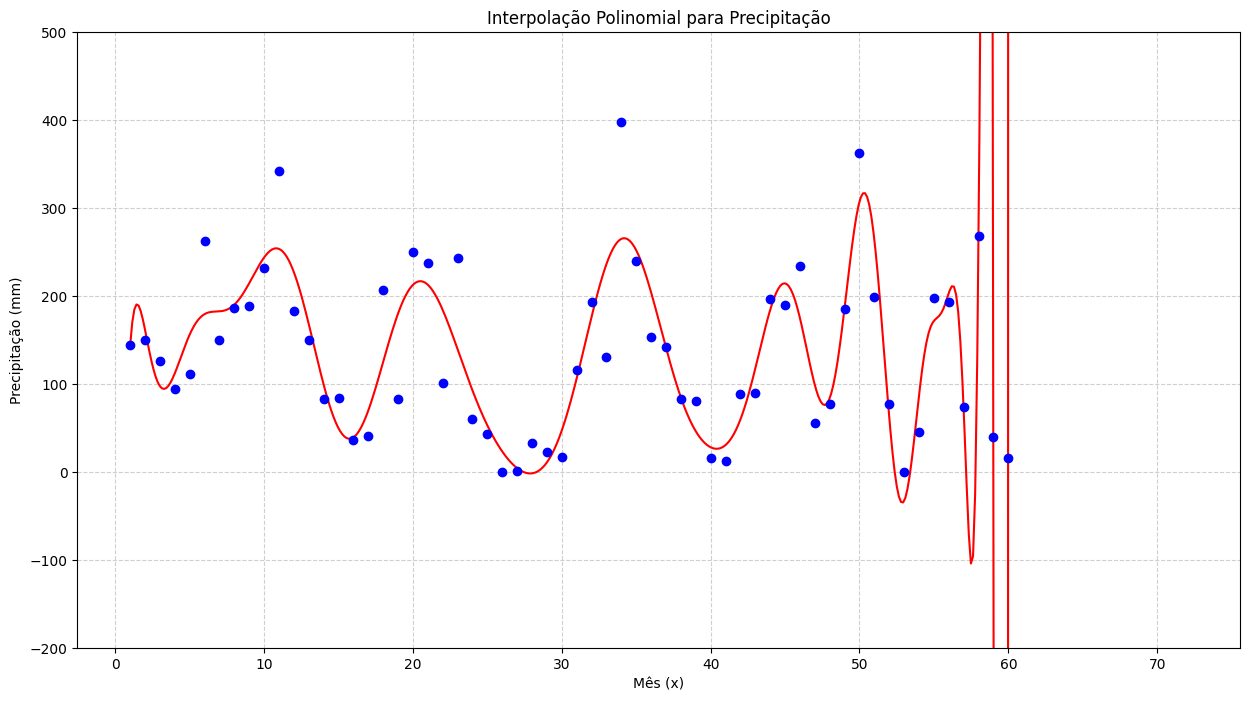

In [71]:
import numpy as np
import matplotlib.pyplot as plt

# --- Interpolação Polinomial ---
# Para 60 pontos, o grau do polinômio que passa por todos é 59.
grau_polinomio = 59

print(f"Ajustando um polinômio de grau {grau_polinomio}...")

# 1. Encontrar os coeficientes do polinômio
# A função pode emitir um aviso "Polyfit may be poorly conditioned", o que é esperado.
coeficientes = np.polyfit(x_dados, y_dados, grau_polinomio)

# 2. Criar a função polinomial a partir dos coeficientes
polinomio_interpolador = np.poly1d(coeficientes)

# 3. Calcular a previsão para o mês 72
mes_futuro = 72
precipitacao_prevista = polinomio_interpolador(mes_futuro)

print(f"\n--- Previsão com Interpolação Polinomial ---")
print(f"A precipitação estimada para o mês {mes_futuro} é: {precipitacao_prevista:e}") # Usando notação científica

# --- Visualização ---
plt.figure(figsize=(15, 8))

# Plotar a curva interpolada
x_curva = np.linspace(1, 72, 500)
y_curva = polinomio_interpolador(x_curva)
plt.plot(x_curva, y_curva, label=f'Polinômio de Grau {grau_polinomio}', color='red')

# Plotar os dados originais
plt.scatter(x_dados, y_dados, label='Dados Originais', color='blue', zorder=5)

plt.title('Interpolação Polinomial para Precipitação')
plt.xlabel('Mês (x)')
plt.ylabel('Precipitação (mm)')
plt.grid(True, linestyle='--', alpha=0.6)

# ATENÇÃO: Vamos limitar o eixo Y para podermos ver os dados originais.
# A curva polinomial "explode" para valores muito altos/baixos.
plt.ylim(-200, 500) # Ajuste este limite para conseguir ver a curva vs. os pontos
plt.show()